# Trajectory Planning for the myCobot 280 Labs
## Lab 6: Trapezoidal Velocity Profiles and Minimum-Time Joint Motion

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Labs 1–5. You will construct smooth point-to-point joint-space trajectories for the myCobot 280 under velocity and acceleration limits. The focus is trapezoidal velocity profiles, the triangular short-move case, minimum-time motion, and practical trajectory sampling for the robot workflow.

All offline calculations in this notebook should be expressed in radians, rad/s, and rad/s² unless a task explicitly starts from the worked example in degrees.

In [1]:
%matplotlib widget
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3

np.set_printoptions(precision=6)

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed alongside this notebook. We use it here mainly to inspect the six-joint structure and to keep the trajectory-planning lab connected to the same myCobot 280 model used in the previous labs.

In [2]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)                         │
│    6 │ joint5         │     3 │ joint4 │ SE3(-0.

/tmp/ipykernel_130283/2264729833.py:3: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


### 2. Inspect the joint-space dimension and limits

Inspect the number of joints and the available joint limits. These limits are not the same as trajectory velocity/acceleration limits, but they are useful when selecting start and goal configurations for trajectory generation.

In [3]:
print('Number of joints:', mycobot.n)
print('Joint limits (if available):')
print(mycobot.qlim)

Number of joints: 6
Joint limits (if available):
[[-2.9322  -2.3562  -2.618   -2.5307  -2.8798  -3.14159]
 [ 2.9322   2.3562   2.618    2.5307   2.8798   3.14159]]


## Scalar Trapezoidal Profile Fundamentals

For a scalar point-to-point move from $q_0$ to $q_f$, the displacement is:

$$\Delta q = q_f - q_0$$

A full trapezoidal profile has:
- **Acceleration phase:** velocity increases linearly from zero to $v_{\max}$, position is quadratic.
- **Constant-velocity cruise phase:** velocity remains at $v_{\max}$, position changes linearly.
- **Deceleration phase:** velocity decreases linearly back to zero, position is quadratic.

If the move is too short to reach $v_{\max}$, the cruise phase disappears and the profile becomes **triangular**.

**Trapezoidal case** ($|\Delta q| > v_{\max}^2 / a_{\max}$):

$$t_a = \frac{v_{\max}}{a_{\max}}, \quad t_c = \frac{|\Delta q| - v_{\max}^2/a_{\max}}{v_{\max}}, \quad t_f = 2t_a + t_c$$

**Triangular case** ($|\Delta q| \leq v_{\max}^2 / a_{\max}$):

$$t_a = \sqrt{\frac{|\Delta q|}{a_{\max}}}, \quad v_{\text{peak}} = a_{\max} \cdot t_a, \quad t_f = 2t_a$$

### 3. Reproduce the worked example from the lab PDF

Use the example:
- $q_0 = 0°$, $q_f = 90°$
- $v_{\max} = 45°/\text{s}$, $a_{\max} = 90°/\text{s}^2$

Expected result: $t_a = 0.5$ s, $t_c = 1.5$ s, $t_f = 2.5$ s (trapezoidal).

In [4]:
q0_deg = 0.0
qf_deg = 90.0
vmax_deg = 45.0
amax_deg = 90.0

dq_deg = qf_deg - q0_deg
dq_abs_deg = abs(dq_deg)

ta = vmax_deg / amax_deg  # Compute the acceleration time from the velocity and acceleration limits
dq_accdec = vmax_deg**2 / amax_deg  # Compute the displacement required for acceleration and deceleration

is_trapezoidal = dq_abs_deg > dq_accdec  # Determine whether the move can reach the velocity limit

if is_trapezoidal:
    tc = (dq_abs_deg - dq_accdec) / vmax_deg  # Compute the constant-velocity duration
    tf = 2 * ta + tc  # Compute the total move duration
else:
    tc = 0.0
    tf = 2 * np.sqrt(dq_abs_deg / amax_deg)
    vpeak = np.sqrt(dq_abs_deg * amax_deg)

print('dq (deg):', dq_deg)
print('ta (s):', ta)
print('dq_accdec (deg):', dq_accdec)
print('trapezoidal:', is_trapezoidal)
print('tc (s):', tc)
print('tf (s):', tf)

dq (deg): 90.0
ta (s): 0.5
dq_accdec (deg): 22.5
trapezoidal: True
tc (s): 1.5
tf (s): 2.5


### 4. Convert the worked example to SI units

Convert the same worked example from degrees to radians, rad/s, and rad/s². Verify that the timing results (`ta`, `tc`, `tf`) are unchanged — they depend on ratios, not on the unit system.

In [5]:
q0 = np.radians(q0_deg)  # Convert the start angle to radians
qf = np.radians(qf_deg)  # Convert the goal angle to radians
vmax = np.radians(vmax_deg)  # Convert the velocity limit to radians per second
amax = np.radians(amax_deg)  # Convert the acceleration limit to radians per second squared

print('q0 (rad):', q0)
print('qf (rad):', qf)
print('vmax (rad/s):', vmax)
print('amax (rad/s^2):', amax)

q0 (rad): 0.0
qf (rad): 1.5707963267948966
vmax (rad/s): 0.7853981633974483
amax (rad/s^2): 1.5707963267948966


### 5. Build the scalar profile timing logic

Implement the timing logic that decides between the trapezoidal and triangular case for a general scalar move. Handle both positive and negative displacements via a `direction` sign.

In [6]:
def scalar_profile_timing(q0, qf, vmax, amax):
    dq = qf - q0
    dq_abs = abs(dq)
    direction = np.sign(dq)  # Determine the direction of motion

    ta_nom = vmax / amax  # Compute the nominal acceleration time
    dq_accdec = vmax**2 / amax  # Compute the displacement needed for acceleration and deceleration

    if dq_abs > dq_accdec:
        # trapezoidal
        ta = ta_nom
        tc = (dq_abs - dq_accdec) / vmax
        tf = 2 * ta + tc
        vpeak = vmax
        profile_type = 'trapezoidal'
    else:
        # triangular
        ta = np.sqrt(dq_abs / amax)  # Compute the acceleration time for a triangular profile
        tc = 0.0
        tf = 2 * ta  # Compute the total duration of the triangular profile
        vpeak = amax * ta  # Compute the peak velocity reached
        profile_type = 'triangular'

    return {
        'dq': dq,
        'dq_abs': dq_abs,
        'direction': direction,
        'ta': ta,
        'tc': tc,
        'tf': tf,
        'vpeak': vpeak,
        'profile_type': profile_type,
    }

timing = scalar_profile_timing(q0, qf, vmax, amax)
timing

{'dq': np.float64(1.5707963267948966),
 'dq_abs': np.float64(1.5707963267948966),
 'direction': np.float64(1.0),
 'ta': np.float64(0.5),
 'tc': np.float64(1.5),
 'tf': np.float64(2.5),
 'vpeak': np.float64(0.7853981633974483),
 'profile_type': 'trapezoidal'}

### 6. Sample the scalar position, velocity, and acceleration profile

Create a sampled scalar trajectory over time for the move above. Use the acceleration, cruise, and deceleration phase definitions explicitly.

During each phase:
- **Acceleration** ($0 \leq t \leq t_a$): $\ddot{q} = \text{dir} \cdot a_{\max}$, $\dot{q} = \text{dir} \cdot a_{\max} \cdot t$, $q = q_0 + \frac{1}{2} \text{dir} \cdot a_{\max} \cdot t^2$
- **Cruise** ($t_a < t \leq t_a + t_c$): $\ddot{q} = 0$, $\dot{q} = \text{dir} \cdot v_{\text{peak}}$, position evolves linearly
- **Deceleration** ($t_a + t_c < t \leq t_f$): $\ddot{q} = -\text{dir} \cdot a_{\max}$, velocity ramps back to zero

In [7]:
def sample_scalar_profile(q0, qf, vmax, amax, dt):
    timing = scalar_profile_timing(q0, qf, vmax, amax)

    ta = timing['ta']
    tc = timing['tc']
    tf = timing['tf']
    direction = timing['direction']
    vpeak = timing['vpeak']

    t = np.arange(0.0, tf + dt, dt)

    q = np.zeros_like(t)
    qd = np.zeros_like(t)
    qdd = np.zeros_like(t)

    for i, ti in enumerate(t):
        if ti <= ta:
            # acceleration phase
            qdd[i] = direction * amax
            qd[i] = direction * amax * ti
            q[i] = q0 + 0.5 * direction * amax * ti**2
        elif ti <= ta + tc:
            # cruise phase
            qdd[i] = 0.0
            qd[i] = direction * vpeak
            q[i] = q0 + 0.5 * direction * amax * ta**2 + direction * vpeak * (ti - ta)  # position at end of accel + cruise distance
        else:
            # deceleration phase
            td = min(ti - (ta + tc), ta)  # time within decel phase
            qdd[i] = -direction * amax if ti < tf else 0.0
            qd[i] = direction * (vpeak - amax * td)
            q[i] = q0 + 0.5 * direction * amax * ta**2 + direction * vpeak * tc + direction * (vpeak * td - 0.5 * amax * td**2)

    return t, q, qd, qdd, timing

t, q, qd, qdd, timing = sample_scalar_profile(q0, qf, vmax, amax, dt=0.01)
print(timing)

{'dq': np.float64(1.5707963267948966), 'dq_abs': np.float64(1.5707963267948966), 'direction': np.float64(1.0), 'ta': np.float64(0.5), 'tc': np.float64(1.5), 'tf': np.float64(2.5), 'vpeak': np.float64(0.7853981633974483), 'profile_type': 'trapezoidal'}


### 7. Plot the scalar trajectory

Plot position, velocity, and acceleration for the sampled scalar profile.

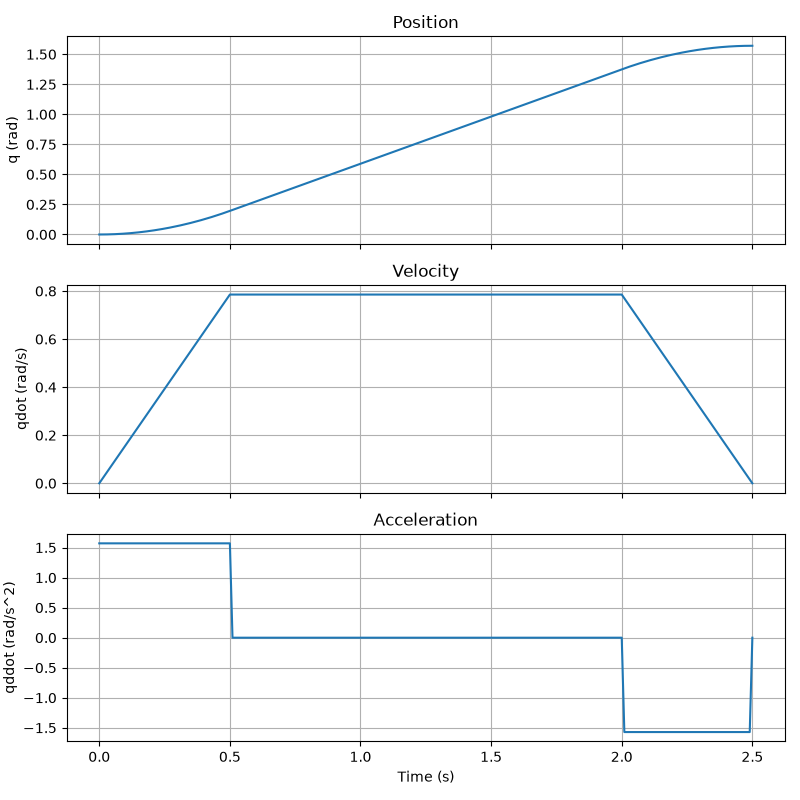

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, q)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Position')
axes[0].grid(True)

axes[1].plot(t, qd)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Velocity')
axes[1].grid(True)

axes[2].plot(t, qdd)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Acceleration')
axes[2].grid(True)

plt.tight_layout()

## Joint-Space Trajectory Planning for the myCobot 280

### 8. Define a start and goal configuration

Choose a safe point-to-point move in joint space for the myCobot 280. Keep the motion moderate and away from obvious joint-limit extremes.

In [9]:
q_start = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0], dtype=float)
q_goal = np.array([np.pi/3, 0.0, -np.pi/2, np.pi/6, np.pi/3, -np.pi/4], dtype=float)

dq = q_goal - q_start
print('q_start:', q_start)
print('q_goal :', q_goal)
print('dq     :', dq)

q_start: [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q_goal : [ 1.047198  0.       -1.570796  0.523599  1.047198 -0.785398]
dq     : [ 1.047198  0.785398 -0.785398  0.523599  0.523599 -0.785398]


### 9. Define velocity and acceleration limits

The myCobot 280 codebase uses a single velocity limit for all joints: `max_joint_speed_deg_s = 150.0` (~2.618 rad/s), and a single acceleration limit: `accel_limit_rad_s2 = 1.0` rad/s². Use these codebase defaults as the planning limits.

In [10]:
# Codebase defaults from mycobot_control.py
vmax_all = np.radians(150.0)  # ~2.618 rad/s
amax_all = 1.0                # rad/s^2

print(f'vmax: {vmax_all:.4f} rad/s ({np.degrees(vmax_all):.1f} deg/s)')
print(f'amax: {amax_all:.4f} rad/s^2')

vmax: 2.6180 rad/s (150.0 deg/s)
amax: 1.0000 rad/s^2


### 10. Compute the minimum motion time for each joint

For each joint, compute the minimum point-to-point motion time under the shared `vmax` and `amax`. Then identify the slowest joint, which determines the synchronized total motion time for the full multi-joint move.

In [11]:
joint_timings = []

for j in range(mycobot.n):
    tj = scalar_profile_timing(q_start[j], q_goal[j], vmax_all, amax_all)
    joint_timings.append(tj)

tf_joint = np.array([tj['tf'] for tj in joint_timings])
tf_sync = np.max(tf_joint)  # Determine the synchronized duration from the per-joint timings

print('Per-joint minimum times:', tf_joint)
print('Synchronized total time:', tf_sync)
print('Time-limiting joint index:', np.argmax(tf_joint))  # Determine which joint requires the longest time

Per-joint minimum times: [2.046653 1.772454 1.772454 1.447203 1.447203 1.772454]
Synchronized total time: 2.046653415892977
Time-limiting joint index: 0


### 11. How the myCobot 280 controller synchronizes joint motion

The codebase's `_build_ee_profile()` uses a different synchronization approach than the per-joint method above. Instead of computing independent per-joint profiles and stretching them to a common time, it:

1. Finds the joint with the **largest displacement** (`max_delta`).
2. Builds a single trapezoidal/triangular velocity profile for that joint.
3. Scales all other joints proportionally: `v_cmd[i] = v_max * (delta[i] / max_delta)`.

This ensures all joints start and finish simultaneously with a single unified profile shape. The practical effect is the same — smooth coordinated motion — but the implementation is simpler because only one profile needs to be computed.

Additionally, the codebase enforces a minimum total time of `ee_min_time_s = 0.5` s. If the computed profile is shorter, the time is clamped and the velocity is reduced accordingly.

### 12. Build synchronized profiles using the codebase approach

Following the `_build_ee_profile()` method from the codebase: identify the joint with the largest displacement, build a single trapezoidal/triangular profile for that joint, then scale all other joints proportionally so they start and finish together.

In [12]:
dt = 0.02

# Find the joint with the largest displacement (codebase: max_delta)
dq_abs = np.abs(dq)
dominant_joint = np.argmax(dq_abs)
max_delta = dq_abs[dominant_joint]

print(f'Dominant joint: {dominant_joint} (|dq| = {max_delta:.4f} rad)')

# Build the profile for the dominant joint
timing_dom = scalar_profile_timing(q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all)
tf_sync = timing_dom['tf']
print(f'Synchronized total time: {tf_sync:.4f} s ({timing_dom["profile_type"]})')

t_sync = np.arange(0.0, tf_sync + dt, dt)

q_traj = np.zeros((len(t_sync), mycobot.n))
qd_traj = np.zeros((len(t_sync), mycobot.n))
qdd_traj = np.zeros((len(t_sync), mycobot.n))

# Sample the dominant joint's profile
t_dom, q_dom, qd_dom, qdd_dom, _ = sample_scalar_profile(
    q_start[dominant_joint], q_goal[dominant_joint], vmax_all, amax_all, dt
)

# For each joint, scale its motion proportionally to the dominant joint
for j in range(mycobot.n):
    if max_delta < 1e-12:
        q_traj[:, j] = q_start[j]
        continue

    ratio = dq[j] / dq[dominant_joint]  # Compute this joint's displacement ratio relative to the dominant joint
    n_pts = min(len(t_sync), len(t_dom))

    for k in range(n_pts):
        q_traj[k, j] = q_start[j] + ratio * (q_dom[k] - q_start[dominant_joint])  # Compute this joint's synchronized position
        qd_traj[k, j] = ratio * qd_dom[k]  # Compute this joint's synchronized velocity
        qdd_traj[k, j] = ratio * qdd_dom[k]  # Compute this joint's synchronized acceleration

    # Fill remaining points if t_sync is longer than t_dom
    if n_pts < len(t_sync):
        q_traj[n_pts:, j] = q_goal[j]

Dominant joint: 0 (|dq| = 1.0472 rad)
Synchronized total time: 2.0467 s (triangular)


### 13. Check the trajectory endpoints and continuity

Verify that:
- the first configuration equals `q_start`
- the last configuration equals `q_goal`
- the start and end velocities are approximately zero

In [13]:
print('q(0):', q_traj[0, :])
print('q(tf):', q_traj[-1, :])
print('qdot(0):', qd_traj[0, :])
print('qdot(tf):', qd_traj[-1, :])

q(0): [ 0.       -0.785398 -0.785398  0.        0.523599  0.      ]
q(tf): [ 1.047198e+00  1.110223e-16 -1.570796e+00  5.235988e-01  1.047198e+00
 -7.853982e-01]
qdot(0): [ 0.  0. -0.  0.  0. -0.]
qdot(tf): [ 0.  0. -0.  0.  0. -0.]


### 14. Plot the multi-joint trajectory

Plot joint position, velocity, and acceleration for all six joints.

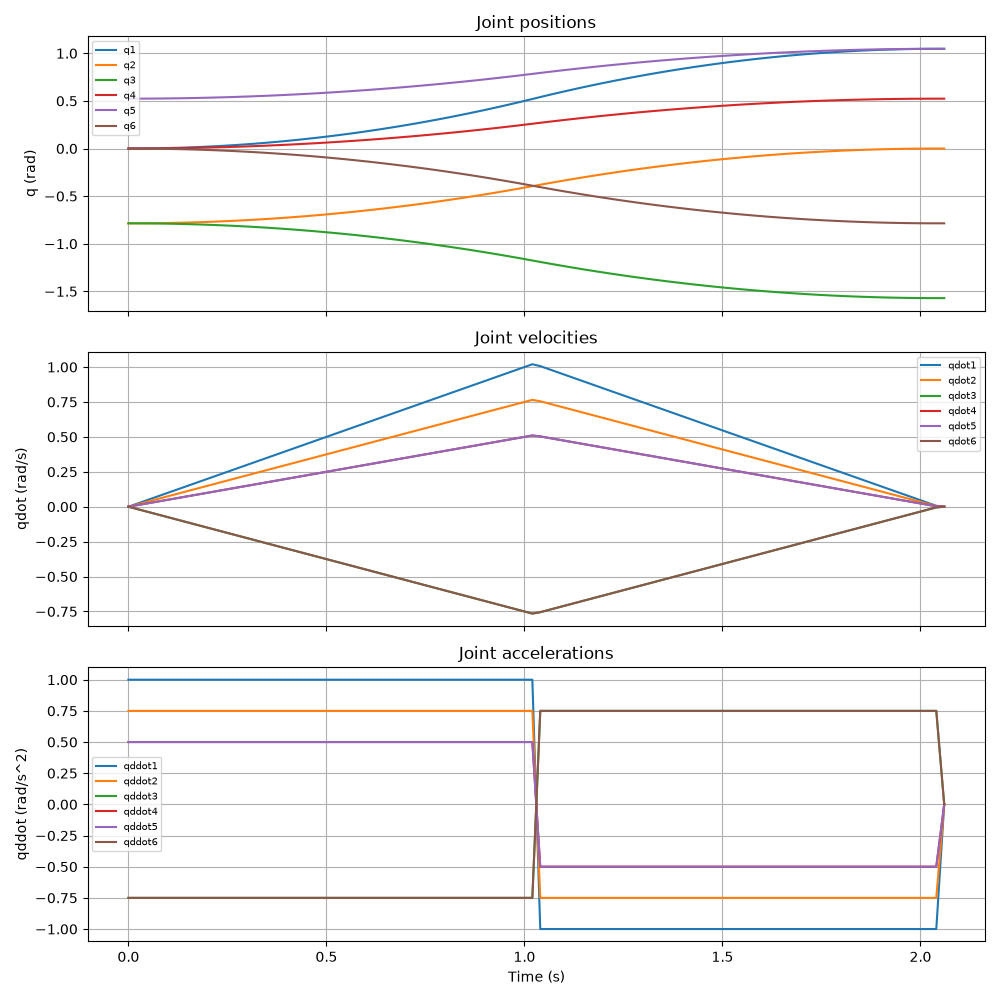

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for j in range(mycobot.n):
    axes[0].plot(t_sync, q_traj[:, j], label=f'q{j+1}')
    axes[1].plot(t_sync, qd_traj[:, j], label=f'qdot{j+1}')
    axes[2].plot(t_sync, qdd_traj[:, j], label=f'qddot{j+1}')

axes[0].set_ylabel('q (rad)')
axes[0].set_title('Joint positions')
axes[0].grid(True)
axes[0].legend(fontsize=7)

axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Joint velocities')
axes[1].grid(True)
axes[1].legend(fontsize=7)

axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Joint accelerations')
axes[2].grid(True)
axes[2].legend(fontsize=7)

plt.tight_layout()

### 15. Check constraint satisfaction

Verify numerically that the generated joint velocity and acceleration profiles do not exceed the specified limits.

In [15]:
qd_peak = np.max(np.abs(qd_traj), axis=0)
qdd_peak = np.max(np.abs(qdd_traj), axis=0)

print('Peak |qdot|:', qd_peak)
print('Velocity limit:', vmax_all)
print('Velocity within limits:', np.all(qd_peak <= vmax_all + 1e-12))  # Check whether all peak velocities satisfy the limit

print('Peak |qddot|:', qdd_peak)
print('Acceleration limit:', amax_all)
print('Acceleration within limits:', np.all(qdd_peak <= amax_all + 1e-12))  # Check whether all peak accelerations satisfy the limit

Peak |qdot|: [1.02  0.765 0.765 0.51  0.51  0.765]
Velocity limit: 2.6179938779914944
Velocity within limits: True
Peak |qddot|: [1.   0.75 0.75 0.5  0.5  0.75]
Acceleration limit: 1.0
Acceleration within limits: True


## Triangular vs Trapezoidal Cases

### 16. Force a short move and observe the triangular profile

Choose a very short scalar move where $|\Delta q| \leq v_{\max}^2 / a_{\max}$ and show that the cruise phase disappears. Compare the resulting timing and profile with the earlier trapezoidal example.

In [16]:
# Short move: small displacement that cannot reach vmax
q0_short = 0.0
qf_short = 0.1  # small value, e.g. 0.1 rad
vmax_short = vmax_all
amax_short = amax_all

t_short, q_short, qd_short, qdd_short, timing_short = sample_scalar_profile(
    q0_short, qf_short, vmax_short, amax_short, dt=0.01
)

print(timing_short)

{'dq': 0.1, 'dq_abs': 0.1, 'direction': np.float64(1.0), 'ta': np.float64(0.31622776601683794), 'tc': 0.0, 'tf': np.float64(0.6324555320336759), 'vpeak': np.float64(0.31622776601683794), 'profile_type': 'triangular'}


### 17. Plot the short-move profile

Plot position, velocity, and acceleration for the short move and confirm visually that the velocity profile is triangular (no flat cruise segment).

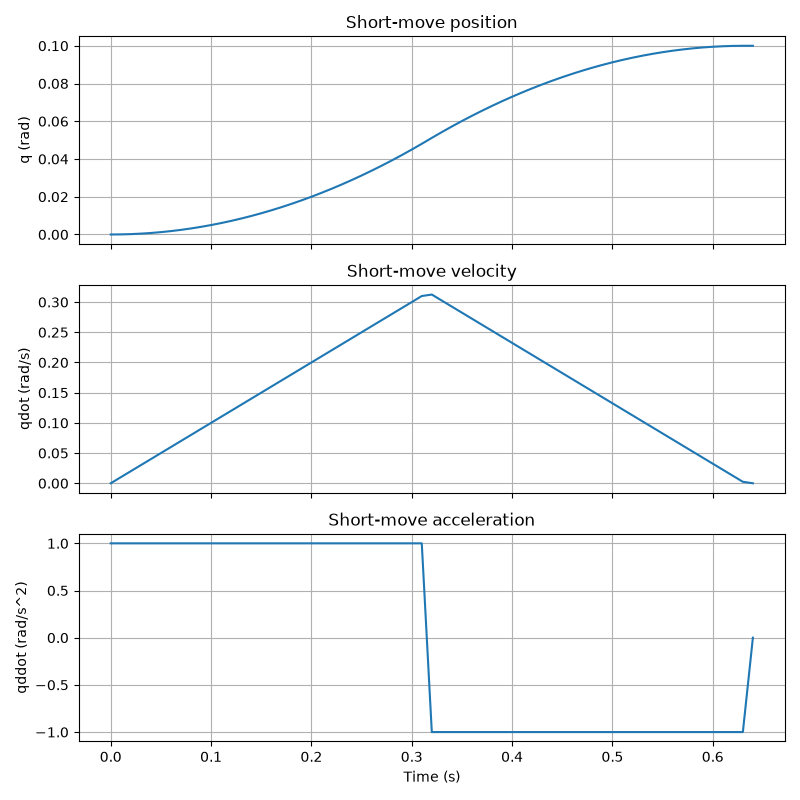

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t_short, q_short)
axes[0].set_ylabel('q (rad)')
axes[0].set_title('Short-move position')
axes[0].grid(True)

axes[1].plot(t_short, qd_short)
axes[1].set_ylabel('qdot (rad/s)')
axes[1].set_title('Short-move velocity')
axes[1].grid(True)

axes[2].plot(t_short, qdd_short)
axes[2].set_ylabel('qddot (rad/s^2)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Short-move acceleration')
axes[2].grid(True)

plt.tight_layout()

## Bridge to the Practical Workflow

### 18. Sample the trajectory for position commands

The generated trajectory can be sampled and sent as a sequence of joint-position commands. In the myCobot stack, this corresponds to publishing sampled joint targets to `/mycobot/joint_command` as a `Float64MultiArray` in **radians**. The controller converts to degrees internally before sending to the hardware.

**Note:** The codebase's `_build_ee_profile()` outputs velocity commands per tick rather than position waypoints — the controller integrates velocities into angle targets at 20 Hz. The position-sampled approach below is a simpler notebook-friendly alternative that achieves the same practical result.

In [18]:
# Inspect the first few sampled joint targets
print('First 5 sampled joint commands (rad):')
print(q_traj[:5, :])

First 5 sampled joint commands (rad):
[[ 0.000000e+00 -7.853982e-01 -7.853982e-01  0.000000e+00  5.235988e-01
   0.000000e+00]
 [ 2.000000e-04 -7.852482e-01 -7.855482e-01  1.000000e-04  5.236988e-01
  -1.500000e-04]
 [ 8.000000e-04 -7.847982e-01 -7.859982e-01  4.000000e-04  5.239988e-01
  -6.000000e-04]
 [ 1.800000e-03 -7.840482e-01 -7.867482e-01  9.000000e-04  5.244988e-01
  -1.350000e-03]
 [ 3.200000e-03 -7.829982e-01 -7.877982e-01  1.600000e-03  5.251988e-01
  -2.400000e-03]]


### 19. Optional ROS 2 bridge to `/mycobot/joint_command`

If the myCobot control stack is running, publish the sampled joint trajectory at a fixed rate. Ensure the controller launch is running in a separate terminal before publishing.

**Important:** `/mycobot/joint_command` expects joint angles in **radians**.

In [19]:
import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)

class TrajectoryCommandNode(Node):
    def __init__(self):
        super().__init__('trajectory_planning_lab_node')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)

traj_node = TrajectoryCommandNode()

publish_traj = False  # set True only when the controller is running

if publish_traj:
    for k in range(len(t_sync)):
        msg = Float64MultiArray()
        msg.data = q_traj[k, :].tolist()  # joint targets in radians
        traj_node.pub.publish(msg)
        rclpy.spin_once(traj_node, timeout_sec=0.0)
        time.sleep(dt)

# Optional cleanup:
# traj_node.destroy_node()
# rclpy.shutdown()